# Estudo de caso: Conv2d no CIFAR-10

Este notebook é um **estudo de caso completo** de classificação de imagens com CNNs em CIFAR-10. Ele assume que os fundamentos de convolução 2D, pooling, shapes e contagem de parâmetros já foram vistos em `notebooks/deep_learning/convnets/conv2d.ipynb`.

Aqui o foco é a pipeline prática:

- carregar e transformar os dados;
- organizar treino, validação e teste;
- treinar uma CNN de ponta a ponta;
- analisar desempenho por classe e exemplos de erro.


## 0. Setup

Vamos usar o `torchvision.datasets.CIFAR10`, evitando o pipeline alternativo com `tgz` e `ImageFolder`. Isso deixa o notebook mais direto e reduz redundâncias.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torchvision.utils import make_grid

torch.manual_seed(0)
np.random.seed(0)


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for path in [start, *start.parents]:
        if (path / 'lecture_notes' / '20_convnets.pdf').exists():
            return path
    return start


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / 'data'
print('Project root:', PROJECT_ROOT)


/Users/ebezerra/miniconda3/envs/cic1205/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: /Users/ebezerra/ailab/cic1205


## 1. Conjunto de dados e transformações

O CIFAR-10 contém imagens RGB de `32 x 32` distribuídas em 10 classes. Como este notebook é um caso completo, vamos separar as transformações de treino e avaliação.


In [2]:
mean = (0.4914, 0.4822, 0.4465)
std = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])


In [3]:
full_train_dataset = datasets.CIFAR10(root=DATA_DIR, train=True, download=True, transform=train_transform)
test_dataset = datasets.CIFAR10(root=DATA_DIR, train=False, download=True, transform=eval_transform)
class_names = full_train_dataset.classes
print(class_names)


100%|██████████| 170498071/170498071 [00:24<00:00, 7068743.17it/s]


Extracting /Users/ebezerra/ailab/cic1205/data/cifar-10-python.tar.gz to /Users/ebezerra/ailab/cic1205/data
Files already downloaded and verified
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [4]:
val_size = 5000
train_size = len(full_train_dataset) - val_size
train_dataset, val_dataset_aug = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42),
)

# A validação deve usar a mesma base de índices, mas sem augmentation.
full_train_eval = datasets.CIFAR10(root=DATA_DIR, train=True, download=False, transform=eval_transform)
val_indices = val_dataset_aug.indices
val_dataset = torch.utils.data.Subset(full_train_eval, val_indices)

print('Train:', len(train_dataset))
print('Val:  ', len(val_dataset))
print('Test: ', len(test_dataset))


Train: 45000
Val:   5000
Test:  10000


In [5]:
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)


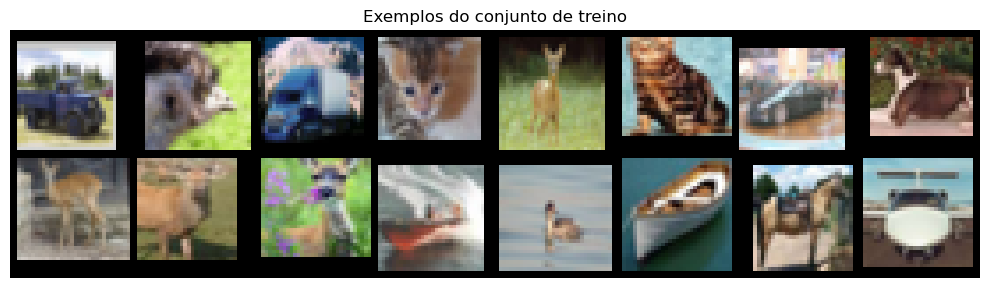

In [6]:
def denormalize(images, mean=mean, std=std):
    mean_t = torch.tensor(mean).view(1, 3, 1, 1)
    std_t = torch.tensor(std).view(1, 3, 1, 1)
    return images * std_t + mean_t


images, labels = next(iter(train_loader))
grid = make_grid(denormalize(images[:16]), nrow=8)
plt.figure(figsize=(10, 5))
plt.imshow(grid.permute(1, 2, 0).clamp(0, 1))
plt.axis('off')
plt.title('Exemplos do conjunto de treino')
plt.tight_layout()


## 2. Modelo CNN

Em vez de repetir a motivação de CNNs, vamos direto para uma arquitetura compacta adequada para CIFAR-10.


In [7]:
class CIFAR10CNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.3),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


model = CIFAR10CNN()
print(model)


CIFAR10CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Dropout(p=0.2, inplace=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (13): Dropout(p=0.3, inplace=False)
    (14): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   

In [8]:
def trace_shapes(model, x):
    print('input', tuple(x.shape))
    for name, module in model.features.named_children():
        x = module(x)
        print(f'features[{name}] {module.__class__.__name__:>12}: {tuple(x.shape)}')
    for name, module in model.classifier.named_children():
        x = module(x)
        print(f'classifier[{name}] {module.__class__.__name__:>10}: {tuple(x.shape)}')
    return x

_ = trace_shapes(model, torch.randn(8, 3, 32, 32))


input (8, 3, 32, 32)
features[0]       Conv2d: (8, 32, 32, 32)
features[1]  BatchNorm2d: (8, 32, 32, 32)
features[2]         ReLU: (8, 32, 32, 32)
features[3]       Conv2d: (8, 32, 32, 32)
features[4]         ReLU: (8, 32, 32, 32)
features[5]    MaxPool2d: (8, 32, 16, 16)
features[6]      Dropout: (8, 32, 16, 16)
features[7]       Conv2d: (8, 64, 16, 16)
features[8]  BatchNorm2d: (8, 64, 16, 16)
features[9]         ReLU: (8, 64, 16, 16)
features[10]       Conv2d: (8, 64, 16, 16)
features[11]         ReLU: (8, 64, 16, 16)
features[12]    MaxPool2d: (8, 64, 8, 8)
features[13]      Dropout: (8, 64, 8, 8)
features[14]       Conv2d: (8, 128, 8, 8)
features[15]  BatchNorm2d: (8, 128, 8, 8)
features[16]         ReLU: (8, 128, 8, 8)
features[17]    MaxPool2d: (8, 128, 4, 4)
classifier[0]    Flatten: (8, 2048)
classifier[1]     Linear: (8, 256)
classifier[2]       ReLU: (8, 256)
classifier[3]    Dropout: (8, 256)
classifier[4]     Linear: (8, 10)


In [9]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print('Parâmetros treináveis:', f'{count_parameters(model):,}')


Parâmetros treináveis: 666,986


## 3. Treinamento

O notebook usa um laço de treino simples, mas completo, com monitoramento de loss e acurácia em treino e validação.


In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print('Device:', device)


Device: cpu


In [11]:
def run_epoch(model, dataloader, criterion, optimizer=None):
    is_training = optimizer is not None
    model.train(is_training)

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for xb, yb in dataloader:
        xb = xb.to(device)
        yb = yb.to(device)

        with torch.set_grad_enabled(is_training):
            logits = model(xb)
            loss = criterion(logits, yb)
            if is_training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        total_loss += loss.detach().cpu().item() * xb.size(0)
        total_correct += (logits.argmax(dim=1) == yb).sum().item()
        total_examples += xb.size(0)

    avg_loss = total_loss / total_examples
    avg_acc = total_correct / total_examples
    return avg_loss, avg_acc


In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 15

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_state = None
best_val_acc = -1.0

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer=optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    print(f'Epoch {epoch:02d} | train_loss={train_loss:.4f} val_loss={val_loss:.4f} train_acc={train_acc:.4f} val_acc={val_acc:.4f}')

model.load_state_dict(best_state)


Epoch 01 | train_loss=1.7293 val_loss=1.3407 train_acc=0.3490 val_acc=0.5096
Epoch 02 | train_loss=1.3871 val_loss=1.0940 train_acc=0.4915 val_acc=0.6004
Epoch 03 | train_loss=1.2279 val_loss=1.1452 train_acc=0.5610 val_acc=0.5920


KeyboardInterrupt: 

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='treino')
axes[0].plot(history['val_loss'], label='validação')
axes[0].set_title('Loss por época')
axes[0].set_xlabel('Época')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(history['train_acc'], label='treino')
axes[1].plot(history['val_acc'], label='validação')
axes[1].set_title('Acurácia por época')
axes[1].set_xlabel('Época')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
plt.tight_layout()


## 4. Avaliação no conjunto de teste

Além da acurácia global, vale olhar o comportamento por classe e examinar previsões corretas e incorretas.


In [ ]:
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        preds = logits.argmax(dim=1).cpu()
        all_preds.append(preds)
        all_targets.append(yb)

all_preds = torch.cat(all_preds)
all_targets = torch.cat(all_targets)

test_acc = (all_preds == all_targets).float().mean().item()
print(f'Acurácia no teste: {test_acc:.4f}')


In [ ]:
num_classes = len(class_names)
conf_mat = torch.zeros(num_classes, num_classes, dtype=torch.int64)
for t, p in zip(all_targets, all_preds):
    conf_mat[t.long(), p.long()] += 1

plt.figure(figsize=(10, 8))
plt.imshow(conf_mat.numpy(), cmap='Blues')
plt.title('Matriz de confusão - teste')
plt.xlabel('Classe prevista')
plt.ylabel('Classe verdadeira')
plt.xticks(range(num_classes), class_names, rotation=45, ha='right')
plt.yticks(range(num_classes), class_names)
plt.colorbar()
plt.tight_layout()


In [ ]:
conf_mat_float = conf_mat.float()
conf_mat_norm = conf_mat_float / conf_mat_float.sum(dim=1, keepdim=True).clamp_min(1.0)

plt.figure(figsize=(10, 8))
plt.imshow(conf_mat_norm.numpy(), cmap='Blues', vmin=0.0, vmax=1.0)
plt.title('Matriz de confusão normalizada')
plt.xlabel('Classe prevista')
plt.ylabel('Classe verdadeira')
plt.xticks(range(num_classes), class_names, rotation=45, ha='right')
plt.yticks(range(num_classes), class_names)
plt.colorbar()
plt.tight_layout()


In [ ]:
class_acc = conf_mat.diag().float() / conf_mat.sum(dim=1).clamp_min(1)
for name, acc in zip(class_names, class_acc):
    print(f'{name:>10}: {acc.item():.3f}')


### Exemplos de previsão


In [ ]:
raw_test_dataset = datasets.CIFAR10(root=DATA_DIR, train=False, download=False, transform=eval_transform)
raw_loader = DataLoader(raw_test_dataset, batch_size=32, shuffle=False)
images, labels = next(iter(raw_loader))

model.eval()
with torch.no_grad():
    logits = model(images.to(device))
    preds = logits.argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()
for i in range(8):
    img = denormalize(images[i:i+1])[0].permute(1, 2, 0).clamp(0, 1).numpy()
    axes[i].imshow(img)
    axes[i].set_title(f'Real: {class_names[labels[i]]}
Pred: {class_names[preds[i]]}')
    axes[i].axis('off')
plt.tight_layout()


## 5. Discussão

Pontos centrais deste estudo de caso:

- augmentation entra apenas no treino;
- validação e teste devem usar transformações determinísticas;
- a matriz de confusão mostra onde o modelo confunde classes visualmente parecidas;
- a curva de treino/validação ajuda a distinguir subajuste, progresso real e overfitting.


## 6. Próximos passos

1. Incluir scheduler de taxa de aprendizado e early stopping.
2. Comparar esta CNN com uma ResNet pequena.
3. Medir precisão e recall por classe, além da acurácia.
4. Inspecionar erros sistemáticos entre classes como `cat`, `dog`, `deer` e `horse`.
